## This notebook can be used to rank a list of nodes from a category that connect to an entity such as a gene. 

In [1]:
from TCT import node_normalizer
from TCT import name_resolver
from TCT import translator_metakg
from TCT import translator_kpinfo
from TCT import translator_query
from TCT import TCT


### Load Translator resources


In [2]:
APInames, metaKG, Translator_KP_info = translator_metakg.load_translator_resources()

In [3]:
All_predicates = list(set(metaKG['Predicate']))
All_categories = list((set(list(set(metaKG['Subject']))+list(set(metaKG['Object'])))))
API_withMetaKG = list(set(metaKG['API']))

    # generate a dictionary of API and its predicates
API_predicates = {}
for api in API_withMetaKG:
    API_predicates[api] = list(set(metaKG[metaKG['API'] == api]['Predicate']))

## Find the neighborhood of an entity from a subset of APIs 


In [4]:
# select a list of APIs to use and a list of predicates to use
selected_APIlist = []

if len(selected_APIlist) == 0:
    select_APIs = APInames
else:
    select_APIs = {k: APInames[k] for k in selected_APIlist if k in APInames}

selected_metaKG = metaKG[metaKG['API'].isin(select_APIs.keys())]
print(select_APIs)
print(selected_metaKG.shape)


{'ARAX Translator Reasoner - TRAPI 1.6.0': 'https://arax.transltr.io/api/arax/v1.4/query/', 'CATRAX Pharmacogenomics KP - TRAPI 1.5.0': 'https://multiomics.rtx.ai:9990/PharmacogenomicsKG/query', 'Text Mined Cooccurrence API': 'https://cooccurrence.transltr.io/query/', 'RTX KG2 - TRAPI 1.5.0': 'https://kg2cploverdb.ci.transltr.io/kg2c/query', 'CATRAX BigGIM DrugResponse Performance Phase KP - TRAPI 1.5.0': 'https://multiomics.rtx.ai:9990/BigGIM_DrugResponse_PerformancePhase/query', 'BioThings Explorer (BTE) TRAPI': 'https://bte.transltr.io/v1/query/', 'Service Provider TRAPI': 'https://bte.transltr.io/v1/team/Service%20Provider/query/', 'Clinical Trials KP - TRAPI 1.5.0': 'https://multiomics.rtx.ai:9990/ctkp/query', 'Gene-List Network Enrichment Analysis': 'https://translator.broadinstitute.org/gelinea-trapi/v1.5/query/', 'Drug Approvals KP - TRAPI 1.5.0': 'https://multiomics.rtx.ai:9990/dakp/query', 'MolePro': 'https://molepro-trapi.transltr.io/molepro/trapi/v1.5/query/', 'Genetics Dat

In order to use the neighborhood finder, we have to look up a CURIE ID for a given term.

In [21]:
name_resolver.lookup('BCL2')
name_resolver.lookup('ABCB1', return_top_response=False, biolink_type='biolink:Gene',  limit=100, only_taxa='NCBITaxon:9606') # sometimes the identifiers are not in the top 1, users need to check the other returned results

[TranslatorNode(curie='NCBIGene:5243', label='ABCB1', types=['biolink:Gene', 'biolink:GeneOrGeneProduct', 'biolink:GenomicEntity', 'biolink:ChemicalEntityOrGeneOrGeneProduct', 'biolink:PhysicalEssence', 'biolink:OntologyClass', 'biolink:BiologicalEntity', 'biolink:ThingWithTaxon', 'biolink:NamedThing', 'biolink:Entity', 'biolink:PhysicalEssenceOrOccurrent', 'biolink:MacromolecularMachineMixin', 'biolink:Protein', 'biolink:GeneProductMixin', 'biolink:Polypeptide', 'biolink:ChemicalEntityOrProteinOrPolypeptide'], synonyms=None, curie_synonyms=None)]

The CURIE ID for acute myeloid leukemia is `MONDO:0018874`. We will use this CURIE ID for subsequent tasks.

Neighborhood finder identifies all nodes *b* that are connected to the given node *a*, where *b* is part of a defined list of categories - returning the neighborhood of node *a*.

In [11]:
input_node_id, result, result_parsed, result_ranked_by_primary_infores = TCT.Neiborhood_finder('NCBIGene:596',
                                                                                            node2_categories = ['biolink:Gene', 'biolink:Protein'],
                                                                                            APInames = select_APIs,
                                                                                            metaKG = selected_metaKG,
                                                                                            API_predicates = API_predicates)     

NCBIGene:596
Automat-genome-alliance(Trapi v1.5.0): Success!
CATRAX Pharmacogenomics KP - TRAPI 1.5.0: Success!
Automat-cam-kp(Trapi v1.5.0): Success!CATRAX BigGIM DrugResponse Performance Phase KP - TRAPI 1.5.0: Success!

RTX KG2 - TRAPI 1.5.0: Success!
Automat-hetionet(Trapi v1.5.0): Success!
Automat-robokop(Trapi v1.5.0): Success!
Service Provider TRAPI: Success!
BioThings Explorer (BTE) TRAPI: Success!
NodeNorm does not know about these identifiers: orphanet:119007


In [8]:
result

{}

NodeNorm does not know about these identifiers: orphanet:119007
[Text(0.5, 0, 'BAX'), Text(2.5, 0, 'MAPK8'), Text(4.5, 0, 'BCL2L11'), Text(6.5, 0, 'FKBP8'), Text(8.5, 0, 'BECN1'), Text(10.5, 0, 'BIK'), Text(12.5, 0, 'CDK1'), Text(14.5, 0, 'ITPR1'), Text(16.5, 0, 'CISD2'), Text(18.5, 0, 'BNIP3'), Text(20.5, 0, 'RAF1'), Text(22.5, 0, 'BMF'), Text(24.5, 0, 'PPP2CA'), Text(26.5, 0, 'SOD1'), Text(28.5, 0, 'CASP3'), Text(30.5, 0, 'BNIP2'), Text(32.5, 0, 'BAG3'), Text(34.5, 0, 'BCL2L10'), Text(36.5, 0, 'PSEN1'), Text(38.5, 0, 'BNIP1'), Text(40.5, 0, 'MAPK14'), Text(42.5, 0, 'RAD9A'), Text(44.5, 0, 'BRCA1'), Text(46.5, 0, 'ITPR1'), Text(48.5, 0, 'SIVA1')]


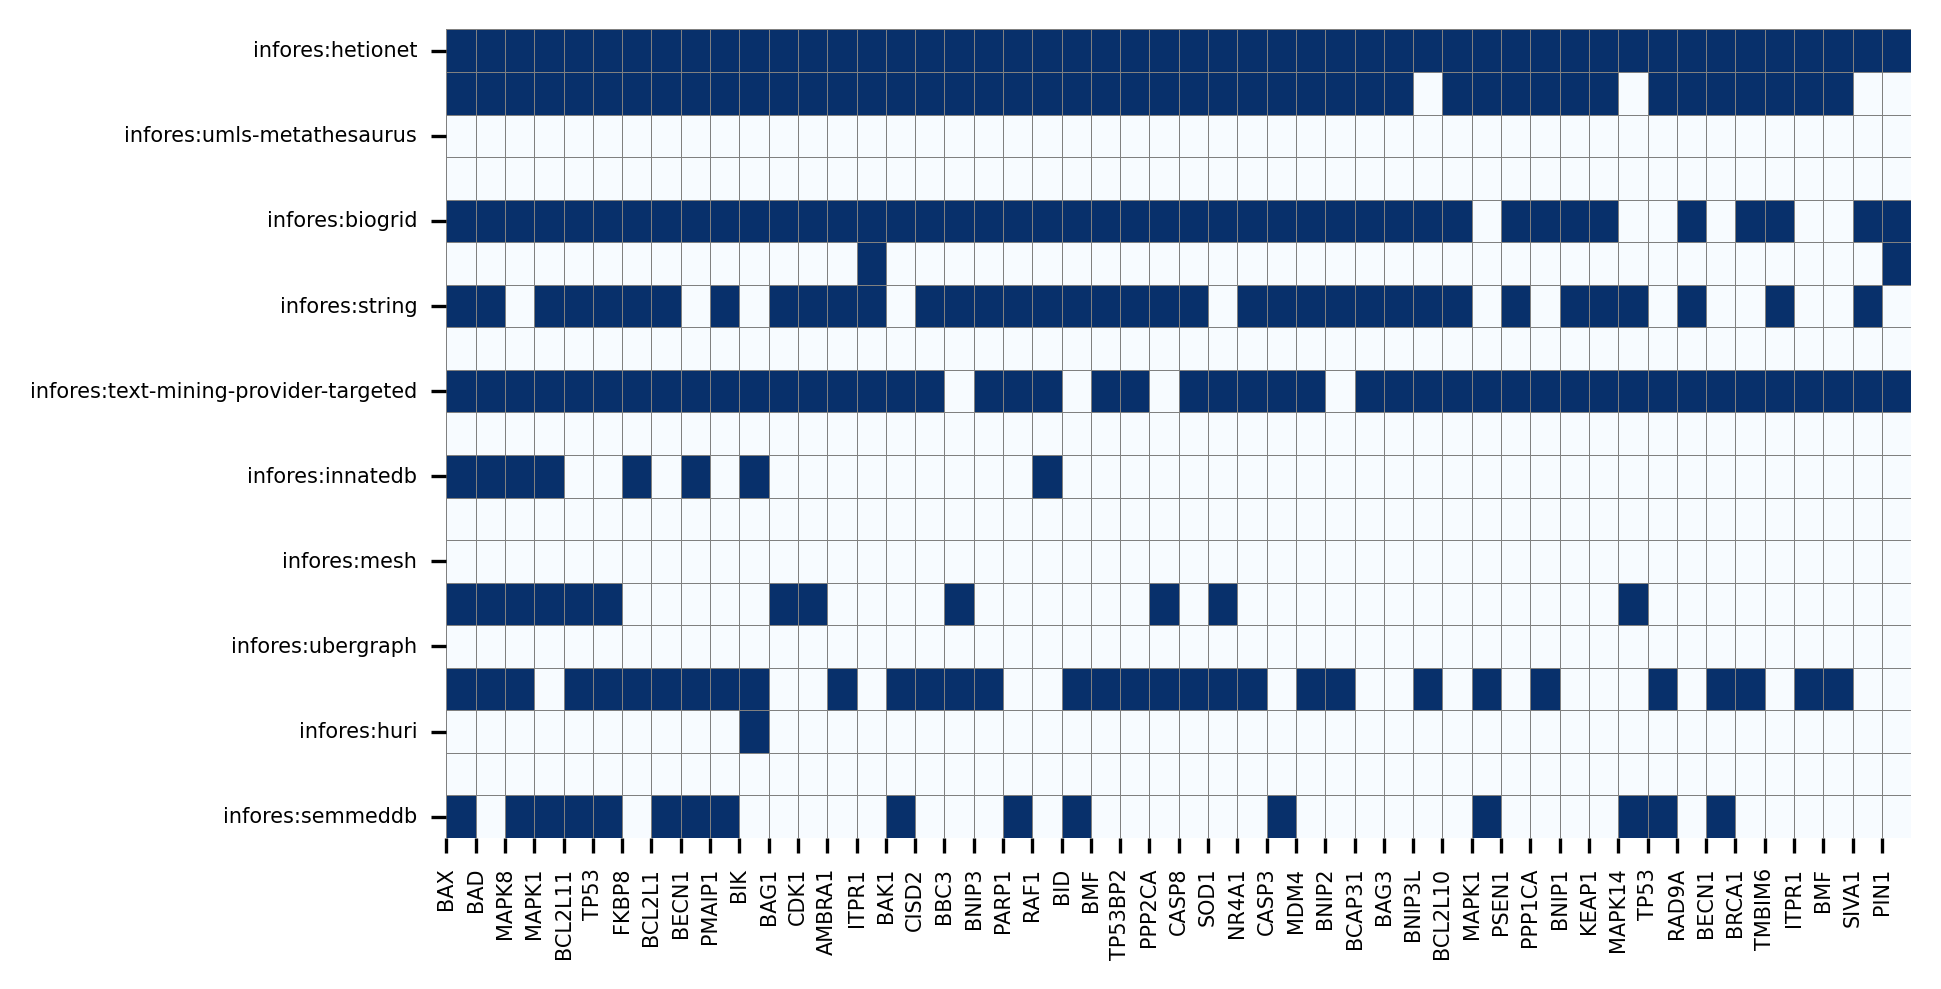

[Text(0.5, 0, 'BAX'), Text(2.5, 0, 'MAPK8'), Text(4.5, 0, 'BCL2L11'), Text(6.5, 0, 'FKBP8'), Text(8.5, 0, 'BECN1'), Text(10.5, 0, 'BIK'), Text(12.5, 0, 'CDK1'), Text(14.5, 0, 'ITPR1'), Text(16.5, 0, 'CISD2'), Text(18.5, 0, 'BNIP3'), Text(20.5, 0, 'RAF1'), Text(22.5, 0, 'BMF'), Text(24.5, 0, 'PPP2CA'), Text(26.5, 0, 'SOD1'), Text(28.5, 0, 'CASP3'), Text(30.5, 0, 'BNIP2'), Text(32.5, 0, 'BAG3'), Text(34.5, 0, 'BCL2L10'), Text(36.5, 0, 'PSEN1'), Text(38.5, 0, 'BNIP1'), Text(40.5, 0, 'MAPK14'), Text(42.5, 0, 'RAD9A'), Text(44.5, 0, 'BRCA1'), Text(46.5, 0, 'ITPR1'), Text(48.5, 0, 'SIVA1')]


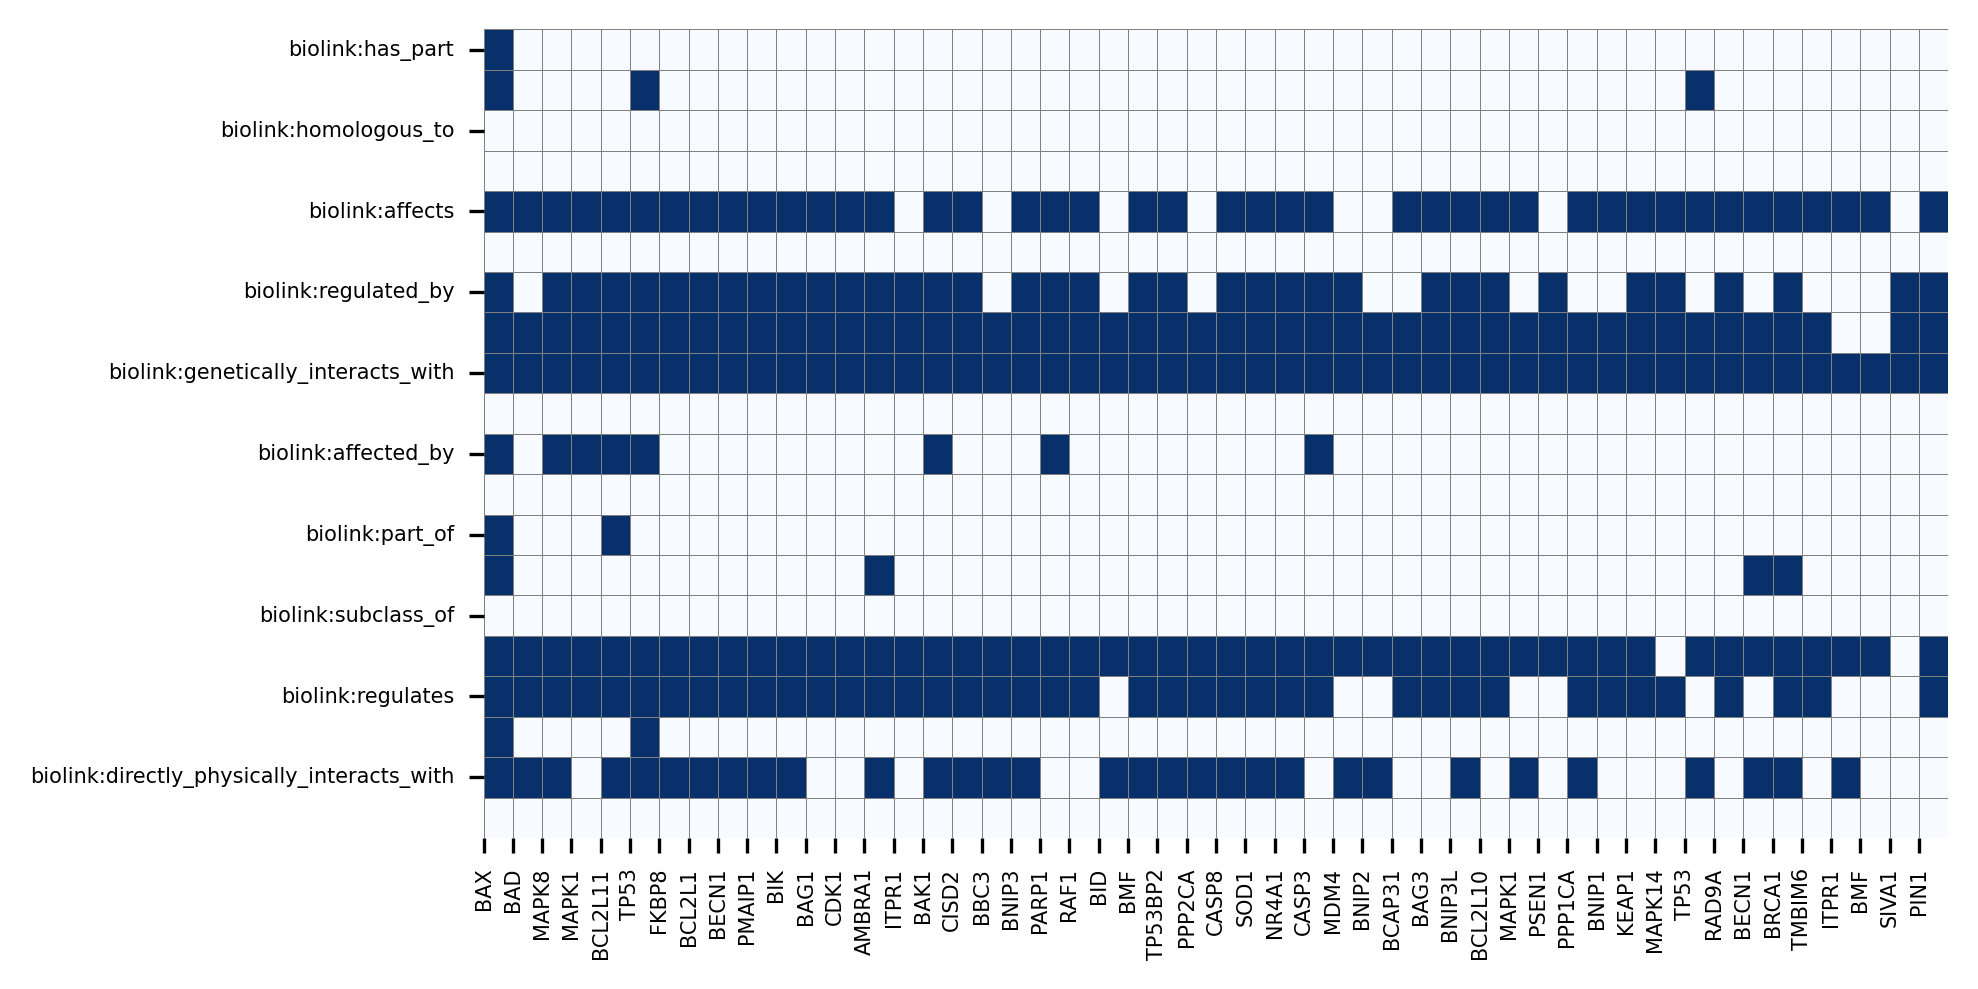

,BAX,BAD,MAPK8,MAPK1,BCL2L11,TP53,FKBP8,BCL2L1,BECN1,PMAIP1,...,SLC12A9,TCF7L1,ATG3,BIRC8_HUMAN Baculoviral IAP repeat-containing protein 8 (sprot),GATA4,ANXA1,LBX1,PPP1R3C,NEUROD1,MMP1
biolink:has_part,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
biolink:coexists_with,1,0,0,0,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
biolink:homologous_to,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
biolink:close_match,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
biolink:affects,1,1,1,1,1,1,1,1,1,1,...,1,1,1,1,1,1,1,1,1,0
biolink:sensitivity_associated_with,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
biolink:regulated_by,1,0,1,1,1,1,1,1,1,1,...,1,0,0,0,0,0,0,0,1,1
biolink:interacts_with,1,1,1,1,1,1,1,1,1,1,...,0,0,0,0,0,0,0,0,0,0
biolink:genetically_interacts_with,1,1,1,1,1,1,1,1,1,1,...,0,0,0,0,0,0,0,0,0,0
biolink:correlated_with,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [12]:
# Step 8: Visualize the results
TCT.visulization_one_hop_ranking(result_ranked_by_primary_infores, result_parsed, 
                                num_of_nodes = 50, input_query = input_node_id, 
                                fontsize = 5)

In [13]:
result_ranked_by_primary_infores

,output_node,Name,Num_of_primary_infores,type_of_nodes,unique_predicates
32,NCBIGene:581,BAX,9,subject,"[biolink:regulates, biolink:physically_interac..."
20,NCBIGene:572,BAD,8,subject,"[biolink:regulates, biolink:physically_interac..."
18,NCBIGene:5599,MAPK8,8,subject,"[biolink:regulates, biolink:physically_interac..."
16,NCBIGene:5594,MAPK1,8,subject,"[biolink:regulates, biolink:physically_interac..."
28,NCBIGene:10018,BCL2L11,8,subject,"[biolink:regulates, biolink:physically_interac..."
...,...,...,...,...,...
1080,NCBIGene:301,ANXA1,1,subject,"[biolink:affects, biolink:regulates, biolink:r..."
1081,NCBIGene:10660,LBX1,1,subject,"[biolink:affects, biolink:regulates, biolink:r..."
1082,NCBIGene:5507,PPP1R3C,1,subject,"[biolink:affects, biolink:regulates, biolink:r..."
1083,NCBIGene:4760,NEUROD1,1,subject,"[biolink:affects, biolink:regulated_by, biolin..."


In [14]:
from TCT import TCT_Visualization

dic_graph = TCT_Visualization.visualize_neighborhood_graph(result, show_label=True, height="500", width="100%")

NodeNorm does not know about these identifiers: orphanet:119007
subclass_of.html


In [16]:
import networkx as nx
from pyvis.network import Network
#G1 = dic_graph['treats']
G2 = dic_graph['directly_physically_interacts_with']
#G3 = dic_graph['_clinical_trials_for']
G_merged = nx.compose_all([G2])
# remove self-loops
G_merged.remove_edges_from(nx.selfloop_edges(G_merged))
# remove duplicate edges
G_merged = nx.Graph(G_merged)
# Select nodes with degree > 10
selected_nodes = ['BCL2']
# select the first neighbors of the selected nodes
for node in list(selected_nodes):
    neighbors = list(G_merged.neighbors(node))
    selected_nodes.extend(neighbors) # expand the selected nodes by adding their neighbors and only keep top 50 nodes
selected_nodes = list(set(selected_nodes))[:100] # keep only top 50 nodes
subgraph = G_merged.subgraph(selected_nodes).copy()

net = Network(height="1000px", width="100%", notebook=True, cdn_resources="in_line")
net.from_nx(subgraph)

# Remove edge labels before passing to PyVis
for u, v, d in subgraph.edges(data=True):
    d.pop("label", None)  # remove 'label' if it exists


for e in net.edges:
    e["title"] = "\n".join([f"{k}: {v}" for k,v in subgraph[e["from"]][e["to"]].items()])
# add title in the figure
title_html = f"<h3>merged_graph</h3>"
net.title = title_html + f"<p>Nodes: {net.num_nodes()} Edges: {net.num_edges()}</p>"
net.show("merged_graph.html")

merged_graph.html


In [19]:
# put G2 into table format
import pandas as pd
edges_data = []
for u, v, d in G2.edges(data=True):
    edge_info = {
        'source': u,
        'target': v,
    }
    edge_info.update(d)  # add all edge attributes
    edges_data.append(edge_info)

edges_df = pd.DataFrame(edges_data)
edges_df.to_csv('BCL2_directly_physically_interacts_with_edges.csv', index=False)

In [30]:
# End of the example
